# 挂载谷歌硬盘，上传数据

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# 安装文泉驿微米黑字体（Ubuntu/Debian 系统）
!apt-get update
!apt-get install -y fonts-wqy-microhei

# 清除 matplotlib 字体缓存
!rm -rf /root/.cache/matplotlib


Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:12 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:13 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelea

In [5]:
import matplotlib as mpl
import matplotlib.font_manager as fm

print("=== 字体搜索路径 ===")
print(mpl.get_data_path() + '/fonts/ttf/')
print("\n=== 可能支持中文的字体 ===")
chinese_fonts = set()
for font in fm.fontManager.ttflist:
    if any(keyword in font.name.lower() for keyword in ['cjk', 'chinese', 'sc', 'noto', 'wenquanyi', 'simhei', 'msyh']):
        chinese_fonts.add(font.name)
for font_name in sorted(chinese_fonts)[:10]:
    print(font_name)

=== 字体搜索路径 ===
/usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/

=== 可能支持中文的字体 ===
Noto Sans CJK JP
Noto Serif CJK JP


# 数据加载与合并

In [ ]:
# ================== 单元格1：加载并合并所有数据，保存为 all_sentences_raw.csv ==================
import pandas as pd
import json
import re

# 1. 微博 CSV 数据
df_weibo = pd.read_csv("/content/drive/MyDrive/5502/project/weibo_leiting.csv")
df_weibo = df_weibo[['sentence']].copy()
df_weibo['source'] = 'weibo'
print(f"微博数据量：{len(df_weibo)}")

# 2. B站视频 JSONL
bili_video_texts = []
with open("/content/drive/MyDrive/5502/project/b_leiting_con.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            text = item.get('title', '')
            if item.get('desc') and item['desc'] not in ['', '-']:
                text += ' ' + item['desc']
            if '雷霆' in text:
                bili_video_texts.append(text)
        except:
            continue
df_bili_video = pd.DataFrame(bili_video_texts, columns=['sentence'])
df_bili_video['source'] = 'bilibili_video'
print(f"B站视频数据量：{len(df_bili_video)}")

# 3. B站评论 JSONL
bili_comment_texts = []
with open("/content/drive/MyDrive/5502/project/b_leiting_com.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            content = item.get('content', '')
            if '雷霆' in content:
                bili_comment_texts.append(content)
        except:
            continue
df_bili_comment = pd.DataFrame(bili_comment_texts, columns=['sentence'])
df_bili_comment['source'] = 'bilibili_comment'
print(f"B站评论数据量：{len(df_bili_comment)}")

# 4. 抖音视频 JSONL
dy_video_texts = []
with open("/content/drive/MyDrive/5502/project/dy_leiting_con.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            text = item.get('title', '')
            if item.get('desc') and item['desc'] not in ['', '-']:
                text += ' ' + item['desc']
            if '雷霆' in text:
                dy_video_texts.append(text)
        except:
            continue
df_dy_video = pd.DataFrame(dy_video_texts, columns=['sentence'])
df_dy_video['source'] = 'dy_video'
print(f"抖音视频数据量：{len(df_dy_video)}")

# 5. 抖音评论 JSONL
dy_comment_texts = []
with open("/content/drive/MyDrive/5502/project/dy_leiting_com.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            content = item.get('content', '')
            if '雷霆' in content:
                dy_comment_texts.append(content)
        except:
            continue
df_dy_comment = pd.DataFrame(dy_comment_texts, columns=['sentence'])
df_dy_comment['source'] = 'dy_comment'
print(f"抖音评论数据量：{len(df_dy_comment)}")

# 6. 小红书文本 JSONL
xhs_cont_texts = []
with open("/content/drive/MyDrive/5502/project/xhs_leiting_con.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            text = item.get('title', '')
            if item.get('desc') and item['desc'] not in ['', '-']:
                text += ' ' + item['desc']
            if '雷霆' in text:
                xhs_cont_texts.append(text)
        except:
            continue
df_xhs_cont = pd.DataFrame(xhs_cont_texts, columns=['sentence'])
df_xhs_cont['source'] = 'xhs_cont'
print(f"小红书视频数据量：{len(df_xhs_cont)}")

# 7. 小红书评论 JSONL
xhs_comment_texts = []
with open("/content/drive/MyDrive/5502/project/xhs_leiting_com.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            content = item.get('content', '')
            if '雷霆' in content:
                xhs_comment_texts.append(content)
        except:
            continue
df_xhs_comment = pd.DataFrame(xhs_comment_texts, columns=['sentence'])
df_xhs_comment['source'] = 'xhs_comment'
print(f"小红书评论数据量：{len(df_xhs_comment)}")



# 4. 合并并保存
df_all = pd.concat([df_weibo, df_bili_video, df_bili_comment, df_dy_video, df_dy_comment, df_xhs_cont, df_xhs_comment], ignore_index=True)
print(f"合并后总数据量：{len(df_all)}")
df_all.to_csv("/content/drive/MyDrive/5502/project/all_sentences_raw.csv",encoding= 'utf-8-sig', index=False)
print("已保存整合数据至 all_sentences_raw.csv")

微博数据量：179
B站视频数据量：286
B站评论数据量：54
抖音视频数据量：294
抖音评论数据量：231
小红书视频数据量：337
小红书评论数据量：45
合并后总数据量：1426
已保存整合数据至 all_sentences_raw.csv


# 数据准备工作

In [ ]:
# ================== 单元格2：清洗文本并筛选网络新义用法（从 all_sentences_raw.csv 读取） ==================
import pandas as pd
import re

# 读取整合好的数据
df_all = pd.read_csv("/content/drive/MyDrive/5502/project/all_sentences_raw.csv")

# 清洗函数
def clean_text(text):
    text = re.sub(r'http\S+', '', str(text))
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#.*?#', '', text)
    text = re.sub(r'[^\w\s\u4e00-\u9fa5]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_all['cleaned_sentence'] = df_all['sentence'].apply(clean_text)
df_all = df_all.drop_duplicates(subset=['cleaned_sentence'])
df_all = df_all[df_all['cleaned_sentence'].str.len() > 5].reset_index(drop=True)
print(f"基础清洗后数据量：{len(df_all)}")

# 黑名单与网络关键词（同前）
BLACKLIST = [
    'NBA', '西部第一', '杜兰特', '卫冕', '亚历山大', '马刺', '季后赛', '冠军',
    '球队', '球员', '主场', '客场', '得分', '篮板', '助攻', '教练', '赛季',
    '雷霆万钧', '雷霆出击', '雷霆手段', '大发雷霆', '小发雷霆', '役使雷霆',
    '雷霆之势', '雷霆一击', '雷霆之怒',
    '雷霆战机', '雷霆反恐', '雷霆行动', '雷霆麻辣烫', '雷霆游戏', '雷霆电竞',
    '扫黑', '警察', '出击', '手段', '之势', '万钧', '之怒',
    '大招', '雷霆跳', '雷霆大跳', '芈月', '吕布', '王者荣耀', '洛克王国', '洛手',
    '践踏', '铁根', '策划', '复刻', '英雄', '技能', '战争雷霆', '雷霆叔叔', '东东'
]

NETWORK_KEYWORDS = [
    '设计', '剧情', '造型', '发型', '角度', '大痘', '翻译', '歌单', '视频',
    '东西', '台词', '运镜', '配色', '版型', '片段', '草稿', '分组', '颜色',
    '大饼', '头像', 'mv', '姿势', '特效', '边框', '播放器', '自拍', '穿搭',
    '洞洞鞋', '皮鞋', '扭腰机', '大灯', '猪脸', '猪头', '表情包', '开屏',
    '刘海', '相机', '书', '食物', '麻辣烫', '粉面菜蛋', '药', '大物', '联名',
    '边框', '小卡', '贴纸', '大图', 'mv'
]

def is_network_meaning(text):
    if any(kw in text for kw in BLACKLIST):
        return False
    if '雷霆' not in text:
        return False
    idx = text.index('雷霆')
    if idx + 2 < len(text):
        next_char = text[idx+2]
        if next_char in ['出', '击', '之', '万', '扫', '怒', '动', '来', '去', '跳']:
            return False
    if any(kw in text for kw in NETWORK_KEYWORDS):
        return True
    return True

df_all['is_network'] = df_all['cleaned_sentence'].apply(is_network_meaning)
network_df = df_all[df_all['is_network'] == True].copy()
literal_df = df_all[df_all['is_network'] == False].copy()
print(f"网络新义句子数：{len(network_df)}")
print(f"传统义句子数：{len(literal_df)}")

# 保存筛选后的数据（可选，供后续分析使用）
network_df.to_csv("/content/drive/MyDrive/5502/project/network_sentences.csv", encoding= 'utf-8-sig', index=False)
literal_df.to_csv("/content/drive/MyDrive/5502/project/literal_sentences.csv", encoding= 'utf-8-sig', index=False)

基础清洗后数据量：1132
网络新义句子数：691
传统义句子数：441


In [ ]:
# ================== 单元格3：从清洗结果生成 MLM 数据与待标注候选 ==================
import pandas as pd
from sklearn.model_selection import train_test_split

# 读取第二步清洗后保存的文件（直接使用清洗结果，不依赖内存变量）
network_df = pd.read_csv("/content/drive/MyDrive/5502/project/network_sentences.csv")
literal_df = pd.read_csv("/content/drive/MyDrive/5502/project/literal_sentences.csv")

print(f"已读取网络新义句子：{len(network_df)} 条")
print(f"已读取传统义句子：{len(literal_df)} 条")

# --- 1. 划分 MLM 继续预训练数据（仅使用网络新义句子）---
if len(network_df) > 0:
    # 注意：清洗后的列名是 'cleaned_sentence'，我们需要它作为文本内容
    mlm_train, mlm_val = train_test_split(
        network_df[['cleaned_sentence']],
        test_size=0.1,
        random_state=42
    )
    # 保存时统一列名为 'sentence'，方便后续 HuggingFace datasets 直接读取
    mlm_train.to_csv("/content/drive/MyDrive/5502/project/mlm_train.csv", index=False, encoding= 'utf-8-sig', header=['sentence'])
    mlm_val.to_csv("/content/drive/MyDrive/5502/project/mlm_val.csv", index=False, encoding= 'utf-8-sig', header=['sentence'])
    print(f"MLM 训练集：{len(mlm_train)} 条，验证集：{len(mlm_val)} 条")
else:
    raise ValueError("未找到任何网络新义句子，请检查清洗步骤！")

# --- 2. 生成待标注候选集（250条：200网络新义 + 50传统义）---
# 从网络新义中随机抽取 200 条（如果不够则取全部）
n_network = min(200, len(network_df))
candidate_network = network_df.sample(n=n_network, random_state=42)

# 从传统义中随机抽取 50 条
n_literal = min(50, len(literal_df))
candidate_literal = literal_df.sample(n=n_literal, random_state=42)

# 合并并只保留文本列
candidate_df = pd.concat([candidate_network, candidate_literal])[['cleaned_sentence']]
candidate_df = candidate_df.rename(columns={'cleaned_sentence': 'sentence'})

# 添加空白标注列，方便人工填写
candidate_df['label'] = ''
candidate_df['note'] = ''

# 随机打乱顺序
candidate_df = candidate_df.sample(frac=1, random_state=42).reset_index(drop=True)

# 保存候选文件
candidate_df.to_csv("/content/drive/MyDrive/5502/project/candidate_for_labeling.csv", encoding= 'utf-8-sig', index=False)
print(f"待标注候选集已保存，共 {len(candidate_df)} 条（预期网络新义 200 条，传统义 50 条）。")
print("请下载该文件，按照三分类标注方案（0=字面义/传统义，1=程度副词，2=评价形容词）进行人工标注。")

已读取网络新义句子：691 条
已读取传统义句子：441 条
MLM 训练集：621 条，验证集：70 条
待标注候选集已保存，共 250 条（预期网络新义 200 条，传统义 50 条）。
请下载该文件，按照三分类标注方案（0=字面义/传统义，1=程度副词，2=评价形容词）进行人工标注。


In [ ]:
import pandas as pd
import re

# 读取清洗好的网络新义数据
network_df = pd.read_csv("/content/drive/MyDrive/5502/project/network_sentences.csv")

# 常见形容词列表（可自行增删）
adj_keywords = ['好吃', '可爱', '好看', '离谱', '搞笑', '无语', '糟糕', '牛逼',
                '抽象', '丑', '帅', '贵', '便宜', '大', '小', '多', '少', '香',
                '甜', '酸', '辣', '咸', '棒', '强', '弱', '难', '容易', '简单']

# 构建正则：雷霆 + 形容词
pattern = r'雷霆(' + '|'.join(adj_keywords) + r')'

mask = network_df['cleaned_sentence'].str.contains(pattern, na=False)
candidates = network_df[mask][['cleaned_sentence']].copy()
candidates = candidates.rename(columns={'cleaned_sentence': 'sentence'})

# 剔除已标注过的句子（避免重复）
labeled_sentences = set(pd.read_csv("/content/drive/MyDrive/5502/project/test_set_labeled.csv")['sentence'])
candidates = candidates[~candidates['sentence'].isin(labeled_sentences)]

# 随机抽取30条供人工筛选
sample_candidates = candidates.sample(n=min(30, len(candidates)), random_state=42)
sample_candidates.to_csv("/content/drive/MyDrive/5502/project/extra_label1_candidates.csv", encoding = "utf-8-sig", index=False)
print(f"已生成 {len(sample_candidates)} 条候选，请从中挑选 15~20 条明确为程度副词的句子。")

已生成 30 条候选，请从中挑选 15~20 条明确为程度副词的句子。


/tmp/ipykernel_7799/2695254756.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = network_df['cleaned_sentence'].str.contains(pattern, na=False)


# 划分人工标注数据集

In [ ]:
# ================== 单元格4：划分训练/测试集 ==================
import pandas as pd
from sklearn.model_selection import train_test_split

labeled_df = pd.read_csv("/content/drive/MyDrive/5502/project/test_set_labeled.csv")

print("各类别分布：")
print(labeled_df['label'].value_counts().sort_index())

# 分层划分，确保训练/测试集中类别比例一致
train_df, test_df = train_test_split(
    labeled_df, test_size=0.3, stratify=labeled_df['label'], random_state=42
)

print(f"\n训练集：{len(train_df)}，测试集：{len(test_df)}")
train_df.to_csv("/content/drive/MyDrive/5502/project/train_set.csv", encoding= 'utf-8-sig', index=False)
test_df.to_csv("/content/drive/MyDrive/5502/project/test_set.csv", encoding= 'utf-8-sig', index=False)

各类别分布：
label
0    90
1    49
2    94
Name: count, dtype: int64

训练集：163，测试集：70


# 模型评估

已设置中文字体：Noto Sans CJK JP

基线1：TF-IDF + SVM

=== 数据加载 ===
训练集样本数：163，测试集样本数：70

训练集类别分布：
label
字面义/传统义    63
程度副词       34
评价形容词      66
Name: count, dtype: int64

测试集类别分布：
label
字面义/传统义    27
程度副词       15
评价形容词      28
Name: count, dtype: int64

=== TF-IDF 向量化 ===
TF-IDF特征维度：414

=== SVM 训练 ===
✅ SVM 训练完成

=== 模型评估 ===

--- 测试集分类报告 ---
              precision    recall  f1-score   support

     字面义/传统义     0.7500    0.2222    0.3429        27
        程度副词     0.0000    0.0000    0.0000        15
       评价形容词     0.4194    0.9286    0.5778        28

    accuracy                         0.4571        70
   macro avg     0.3898    0.3836    0.3069        70
weighted avg     0.4570    0.4571    0.3634        70


=== 结果保存 ===
✅ 分类报告已保存至：/content/drive/MyDrive/5502/project/result/svm/baseline1_svm_report.txt


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

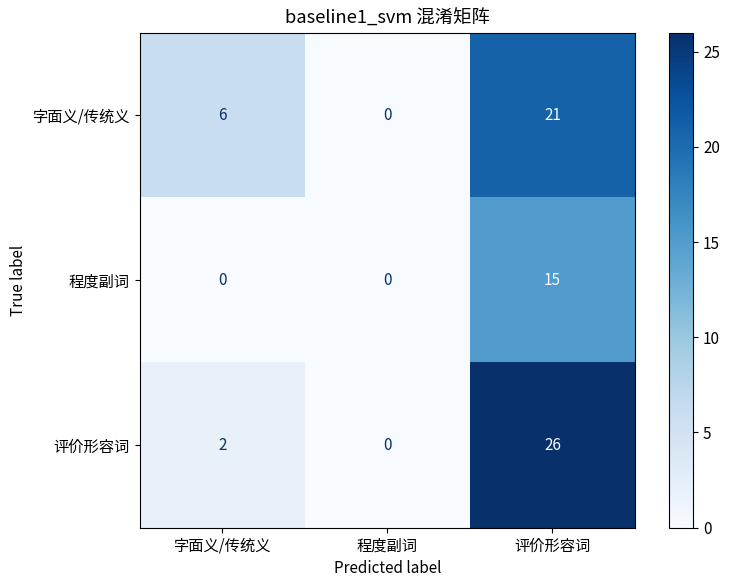

✅ 混淆矩阵图片已保存至：/content/drive/MyDrive/5502/project/result/svm/baseline1_svm_confusion_matrix.png
✅ 详细预测结果已保存至：/content/drive/MyDrive/5502/project/result/svm/baseline1_svm_predictions.csv

🎉 基线1（TF-IDF + SVM）实验完成！


In [9]:
# ================== 单元格4：基线1：TF-IDF + SVM（已优化，与单元格6风格一致） ==================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import os
import random
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

# ---------- 全局配置与种子固定（与单元格6保持一致） ----------
def set_seed(seed=42):
    """固定所有随机种子，确保实验可复现"""
    random.seed(seed)
    np.random.seed(seed)

set_seed(42)

# 中文字体配置（用户已配置，保留原设置）
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'Noto Serif CJK JP', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
print("已设置中文字体：Noto Sans CJK JP")

# ---------- 辅助函数（与单元格6保持一致的结果保存逻辑） ----------
def save_results(y_true, y_pred, target_names, output_dir, model_desc, train_size=None, test_size=None):
    """保存分类报告、混淆矩阵和预测详情（与单元格6函数签名完全一致）

    Args:
        y_true: 真实标签数组
        y_pred: 预测标签数组
        target_names: 标签名称列表
        output_dir: 结果保存目录
        model_desc: 模型描述，用于文件名
        train_size: 训练集大小（可选）
        test_size: 测试集大小（可选）

    Returns:
        分类报告字符串
    """
    os.makedirs(output_dir, exist_ok=True)

    # 分类报告（digits=4，与单元格6精度一致）
    report = classification_report(y_true, y_pred, target_names=target_names, digits=4)
    report_path = os.path.join(output_dir, f"{model_desc}_report.txt")
    with open(report_path, "w", encoding="utf-8") as f:
        f.write(f"=== {model_desc} 分类报告 ===\n")
        if train_size:
            f.write(f"训练集大小：{train_size} 条\n")
        if test_size:
            f.write(f"测试集大小：{test_size} 条\n\n")
        f.write(report)
    print(f"✅ 分类报告已保存至：{report_path}")

    # 混淆矩阵图（与单元格6样式一致）
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, cmap=plt.cm.Blues, values_format='d')
    plt.title(f"{model_desc} 混淆矩阵")
    plt.tight_layout()
    cm_path = os.path.join(output_dir, f"{model_desc}_confusion_matrix.png")
    plt.savefig(cm_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ 混淆矩阵图片已保存至：{cm_path}")

    return report

# ---------- 主执行流程（与单元格6结构对齐） ----------
if __name__ == "__main__":
    print("\n" + "="*60)
    print("基线1：TF-IDF + SVM")
    print("="*60)

    # 统一路径管理（与单元格6一致）
    BASE_DIR = "/content/drive/MyDrive/5502/project"
    output_dir = f"{BASE_DIR}/result/svm"
    os.makedirs(output_dir, exist_ok=True)

    # 1. 读取数据
    print("\n=== 数据加载 ===")
    train_df = pd.read_csv(f"{BASE_DIR}/train_set.csv")
    test_df = pd.read_csv(f"{BASE_DIR}/test_set.csv")

    target_names = ["字面义/传统义", "程度副词", "评价形容词"]

    print(f"训练集样本数：{len(train_df)}，测试集样本数：{len(test_df)}")
    print("\n训练集类别分布：")
    print(train_df['label'].value_counts().sort_index().rename(lambda x: target_names[x]))
    print("\n测试集类别分布：")
    print(test_df['label'].value_counts().sort_index().rename(lambda x: target_names[x]))

    # 2. 提取文本和标签
    X_train = train_df['sentence'].astype(str).values
    y_train = train_df['label'].values
    X_test = test_df['sentence'].astype(str).values
    y_test = test_df['label'].values

    # 3. TF-IDF 向量化
    print("\n=== TF-IDF 向量化 ===")
    vectorizer = TfidfVectorizer(max_features=1000)
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)
    print(f"TF-IDF特征维度：{X_train_tfidf.shape[1]}")

    # 4. 训练 SVM（线性核，固定随机种子）
    print("\n=== SVM 训练 ===")
    clf = SVC(kernel='linear', random_state=42)
    clf.fit(X_train_tfidf, y_train)
    print("✅ SVM 训练完成")

    # 5. 预测与评估
    print("\n=== 模型评估 ===")
    y_pred = clf.predict(X_test_tfidf)

    # 打印分类报告
    print("\n--- 测试集分类报告 ---")
    print(classification_report(y_test, y_pred, target_names=target_names, digits=4))

    # 6. 保存结果（复用与单元格6一致的函数）
    print("\n=== 结果保存 ===")
    save_results(
        y_test, y_pred, target_names, output_dir,
        "baseline1_svm",
        train_size=len(train_df),
        test_size=len(test_df)
    )

    # 7. 保存预测结果 CSV（添加标签名称，与单元格6一致）
    pred_df = pd.DataFrame({
        'sentence': X_test,
        'true_label': y_test,
        'true_label_name': [target_names[l] for l in y_test],
        'pred_label': y_pred,
        'pred_label_name': [target_names[l] for l in y_pred]
    })
    pred_csv_path = os.path.join(output_dir, "baseline1_svm_predictions.csv")
    pred_df.to_csv(pred_csv_path, index=False, encoding='utf-8-sig')
    print(f"✅ 详细预测结果已保存至：{pred_csv_path}")

    print("\n" + "="*60)
    print("🎉 基线1（TF-IDF + SVM）实验完成！")
    print("="*60)

GPU可用: True
当前使用GPU: Tesla T4
已设置中文字体：Noto Sans CJK JP

MLM继续预训练：BERT-base-chinese → 雷霆网络新义领域

=== 数据加载 ===
MLM训练集句子数：621，验证集句子数：70
特殊掩码词：['雷霆']，掩码概率：50%

=== 数据Tokenize ===


Map:   0%|          | 0/621 [00:00<?, ? examples/s]

Map:   0%|          | 0/70 [00:00<?, ? examples/s]

✅ 数据Tokenize完成，最大序列长度：64

=== 初始化数据整理器 ===
✅ 自定义数据整理器初始化完成

=== 加载预训练模型 ===


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

✅ MLM继续预训练完成

=== 保存最优模型 ===


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ 最优模型已保存至：/content/drive/MyDrive/5502/project/thunder_mlm_final

=== 生成困惑度曲线 ===


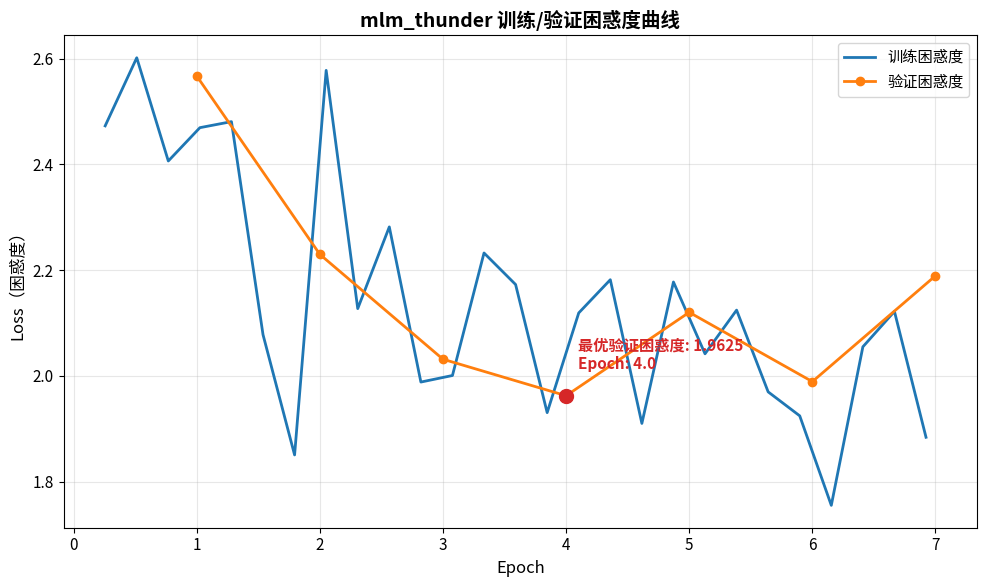

✅ 困惑度曲线已保存至：/content/drive/MyDrive/5502/project/result/mlm/mlm_thunder_perplexity_curve.png

=== 清理中间checkpoint ===
✅ 中间checkpoint已清理

🎉 MLM继续预训练全部完成！
💡 下一步：请运行【单元格6】进行基线2与我们的模型对比


In [17]:
# ================== 单元格5：MLM继续预训练（修复overwrite_output_dir兼容问题） ==================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import os
import random
import shutil
import torch
from transformers import (
    BertTokenizer, BertForMaskedLM,
    Trainer, TrainingArguments, DataCollatorForLanguageModeling,
    EarlyStoppingCallback
)
from datasets import Dataset

# ---------- 全局配置与种子固定 ----------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

print("GPU可用:", torch.cuda.is_available())
if not torch.cuda.is_available():
    print("⚠️ 警告：未检测到GPU，训练将使用CPU，速度会非常慢！")
else:
    print(f"当前使用GPU: {torch.cuda.get_device_name(0)}")

# 中文字体配置
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'Noto Serif CJK JP', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
print("已设置中文字体：Noto Sans CJK JP")

# ---------- 全局路径配置 ----------
BASE_DIR = "/content/drive/MyDrive/5502/project"
MODEL_OUTPUT_DIR = f"{BASE_DIR}/thunder_mlm_final"
MLM_RESULT_DIR = f"{BASE_DIR}/result/mlm"
TEMP_CHECKPOINT_DIR = f"{BASE_DIR}/temp_mlm_checkpoints"

os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)
os.makedirs(MLM_RESULT_DIR, exist_ok=True)

# ---------- 自定义MLM数据整理器（“雷霆”50%掩码） ----------
class CustomMLMDataCollator(DataCollatorForLanguageModeling):
    def __init__(self, tokenizer, mlm=True, mlm_probability=0.15, special_mask_tokens=None, special_mask_prob=0.5):
        super().__init__(tokenizer=tokenizer, mlm=mlm, mlm_probability=mlm_probability)
        self.special_mask_tokens = special_mask_tokens or []
        self.special_mask_prob = special_mask_prob
        self.special_mask_token_ids = [
            self.tokenizer.convert_tokens_to_ids(list(word))
            for word in self.special_mask_tokens
        ]

    def mask_tokens(self, inputs, special_tokens_mask=None):
        labels = inputs.clone()
        probability_matrix = torch.full(labels.shape, self.mlm_probability)

        if special_tokens_mask is None:
            special_tokens_mask = [
                self.tokenizer.get_special_tokens_mask(val, already_has_special_tokens=True)
                for val in labels.tolist()
            ]
            special_tokens_mask = torch.tensor(special_tokens_mask, dtype=torch.bool)
        else:
            special_tokens_mask = special_tokens_mask.bool()
        probability_matrix.masked_fill_(special_tokens_mask, value=0.0)

        for special_ids in self.special_mask_token_ids:
            special_len = len(special_ids)
            if special_len == 0:
                continue
            for i in range(labels.shape[0]):
                sentence = labels[i].tolist()
                for j in range(len(sentence) - special_len + 1):
                    if sentence[j:j+special_len] == special_ids:
                        if random.random() < self.special_mask_prob:
                            probability_matrix[i, j:j+special_len] = 1.0

        masked_indices = torch.bernoulli(probability_matrix).bool()
        labels[~masked_indices] = -100

        indices_replaced = torch.bernoulli(torch.full(labels.shape, 0.8)).bool() & masked_indices
        inputs[indices_replaced] = self.tokenizer.convert_tokens_to_ids(self.tokenizer.mask_token)

        indices_random = torch.bernoulli(torch.full(labels.shape, 0.5)).bool() & masked_indices & ~indices_replaced
        random_words = torch.randint(len(self.tokenizer), labels.shape, dtype=torch.long)
        inputs[indices_random] = random_words[indices_random]

        return inputs, labels

# ---------- 困惑度曲线保存函数 ----------
def save_perplexity_curve(trainer, output_dir, model_desc):
    os.makedirs(output_dir, exist_ok=True)

    log_history = trainer.state.log_history
    train_loss, train_steps = [], []
    val_loss, val_epochs = [], []

    for log in log_history:
        if "loss" in log and "epoch" in log:
            train_loss.append(log["loss"])
            train_steps.append(log["epoch"])
        if "eval_loss" in log and "epoch" in log:
            val_loss.append(log["eval_loss"])
            val_epochs.append(log["epoch"])

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(train_steps, train_loss, label="训练困惑度", color="#1f77b4", linewidth=2)
    ax.plot(val_epochs, val_loss, label="验证困惑度", color="#ff7f0e", linewidth=2, marker="o")

    if val_loss:
        min_val_loss = min(val_loss)
        min_val_epoch = val_epochs[val_loss.index(min_val_loss)]
        ax.scatter(min_val_epoch, min_val_loss, color="#d62728", s=100, zorder=5)
        ax.text(min_val_epoch + 0.1, min_val_loss + 0.05,
                f"最优验证困惑度: {min_val_loss:.4f}\nEpoch: {min_val_epoch}",
                color="#d62728", fontweight="bold")

    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel("Loss（困惑度）", fontsize=12)
    ax.set_title(f"{model_desc} 训练/验证困惑度曲线", fontsize=14, fontweight="bold")
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)
    plt.tight_layout()

    curve_path = os.path.join(output_dir, f"{model_desc}_perplexity_curve.png")
    plt.savefig(curve_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ 困惑度曲线已保存至：{curve_path}")

# ---------- 主执行流程 ----------
if __name__ == "__main__":
    print("\n" + "="*60)
    print("MLM继续预训练：BERT-base-chinese → 雷霆网络新义领域")
    print("="*60)

    # 配置参数
    SPECIAL_MASK_WORDS = ["雷霆"]
    SPECIAL_MASK_PROB = 0.5
    DEFAULT_MLM_PROB = 0.15
    MAX_SEQ_LEN = 64
    TRAIN_BATCH_SIZE = 16
    EVAL_BATCH_SIZE = 16
    NUM_TRAIN_EPOCHS = 10
    EARLY_STOPPING_PATIENCE = 3
    LEARNING_RATE = 2e-5

    # 1. 读取数据
    print("\n=== 数据加载 ===")
    mlm_train_path = f"{BASE_DIR}/mlm_train.csv"
    mlm_val_path = f"{BASE_DIR}/mlm_val.csv"

    if not os.path.exists(mlm_train_path) or not os.path.exists(mlm_val_path):
        print(f"\n❌ 错误：未找到MLM训练/验证数据！")
        print(f"💡 提示：请先运行数据清洗单元格")
        exit()

    train_df = pd.read_csv(mlm_train_path)
    val_df = pd.read_csv(mlm_val_path)
    print(f"MLM训练集句子数：{len(train_df)}，验证集句子数：{len(val_df)}")
    print(f"特殊掩码词：{SPECIAL_MASK_WORDS}，掩码概率：{SPECIAL_MASK_PROB*100:.0f}%")

    # 2. Tokenize
    print("\n=== 数据Tokenize ===")
    tokenizer = BertTokenizer.from_pretrained("bert-base-chinese")

    def tokenize_function(examples):
        return tokenizer(examples["sentence"], padding="max_length", truncation=True, max_length=MAX_SEQ_LEN)

    train_ds = Dataset.from_pandas(train_df[['sentence']])
    val_ds = Dataset.from_pandas(val_df[['sentence']])
    tokenized_train = train_ds.map(tokenize_function, batched=True, remove_columns=["sentence"])
    tokenized_val = val_ds.map(tokenize_function, batched=True, remove_columns=["sentence"])
    print(f"✅ 数据Tokenize完成，最大序列长度：{MAX_SEQ_LEN}")

    # 3. 数据整理器
    print("\n=== 初始化数据整理器 ===")
    data_collator = CustomMLMDataCollator(
        tokenizer=tokenizer,
        mlm=True,
        mlm_probability=DEFAULT_MLM_PROB,
        special_mask_tokens=SPECIAL_MASK_WORDS,
        special_mask_prob=SPECIAL_MASK_PROB
    )
    print("✅ 自定义数据整理器初始化完成")

    # 4. 加载模型
    print("\n=== 加载预训练模型 ===")
    model = BertForMaskedLM.from_pretrained("bert-base-chinese")
    print("✅ 原生BERT-base-chinese模型加载完成")

    # 5. 训练参数（已移除overwrite_output_dir）
    print("\n=== 设置训练参数 ===")
    # 清理可能存在的旧临时目录
    shutil.rmtree(TEMP_CHECKPOINT_DIR, ignore_errors=True)

    training_args = TrainingArguments(
        output_dir=TEMP_CHECKPOINT_DIR,
        num_train_epochs=NUM_TRAIN_EPOCHS,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_steps=10,
        learning_rate=LEARNING_RATE,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        seed=42,
        report_to="none",
    )
    print(f"✅ 训练参数设置完成（早停耐心值：{EARLY_STOPPING_PATIENCE}）")

    # 6. Trainer
    print("\n=== 初始化Trainer ===")
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_val,
        data_collator=data_collator,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
    )
    print("✅ Trainer初始化完成")

    # 7. 训练
    print("\n=== 开始MLM继续预训练 ===")
    trainer.train()
    print("✅ MLM继续预训练完成")

    # 8. 保存模型
    print("\n=== 保存最优模型 ===")
    trainer.save_model(MODEL_OUTPUT_DIR)
    tokenizer.save_pretrained(MODEL_OUTPUT_DIR)
    print(f"✅ 最优模型已保存至：{MODEL_OUTPUT_DIR}")

    # 9. 困惑度曲线
    print("\n=== 生成困惑度曲线 ===")
    save_perplexity_curve(trainer, MLM_RESULT_DIR, "mlm_thunder")

    # 10. 清理中间checkpoint
    print("\n=== 清理中间checkpoint ===")
    shutil.rmtree(TEMP_CHECKPOINT_DIR, ignore_errors=True)
    print("✅ 中间checkpoint已清理")

    print("\n" + "="*60)
    print("🎉 MLM继续预训练全部完成！")
    print("💡 下一步：请运行【单元格6】进行基线2与我们的模型对比")
    print("="*60)

GPU可用: True
当前使用GPU: Tesla T4
已设置中文字体：Noto Sans CJK JP

开始实验：基线2（原生BERT） vs 我们的模型（BERT+MLM）
训练集大小：163，测试集大小：70
训练集类别分布：
label
0    63
1    34
2    66
Name: count, dtype: int64
测试集类别分布：
label
0    27
1    15
2    28
Name: count, dtype: int64

baseline2_bert


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-chinese
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



=== 计算 bert-base-chinese 的MLM困惑度 ===


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

...

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-chinese
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,No log,1.059782,0.500000,0.350877
2,1.076232,0.998682,0.593750,0.444171
3,0.825109,0.971304,0.562500,0.416667


Fold 5 准确率: 0.5625, 宏平均F1: 0.4167
已清理临时目录：./temp_fold_4

--- 5折交叉验证汇总结果 ---
准确率: 0.5576 ± 0.0781
宏平均F1: 0.4333 ± 0.0800
验证损失: 0.8826 ± 0.1039
✅ 5折CV分类报告已保存至：/content/drive/MyDrive/5502/project/result/bert/baseline2_bert_5fold_cv_report.txt


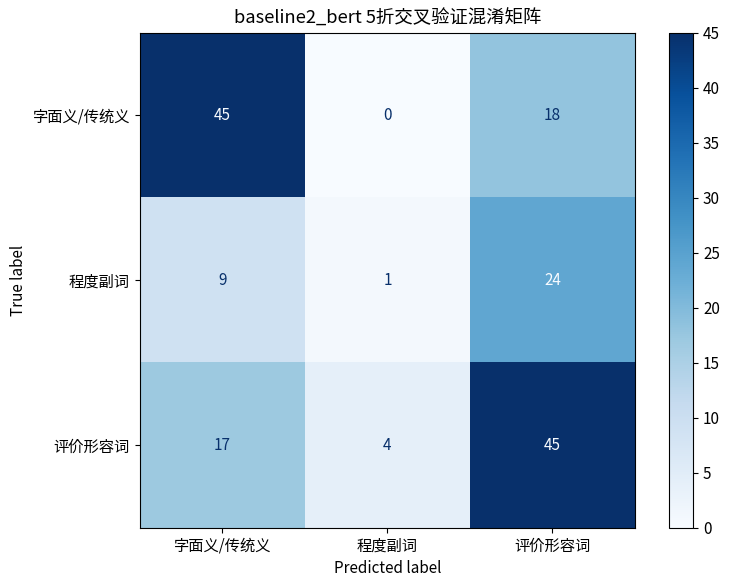

✅ 5折CV混淆矩阵已保存至：/content/drive/MyDrive/5502/project/result/bert/baseline2_bert_5fold_cv_confusion_matrix.png

=== 开始完整训练集训练与测试集评估 ===


Map:   0%|          | 0/163 [00:00<?, ? examples/s]

Map:   0%|          | 0/70 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-chinese
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
20,1.109754
40,0.973740
60,0.820480


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


--- 最终测试集结果 ---
准确率: 0.5286
宏平均F1: 0.4565
MLM困惑度: 12.2107
✅ 分类报告已保存至：/content/drive/MyDrive/5502/project/result/bert/baseline2_bert_test_report.txt


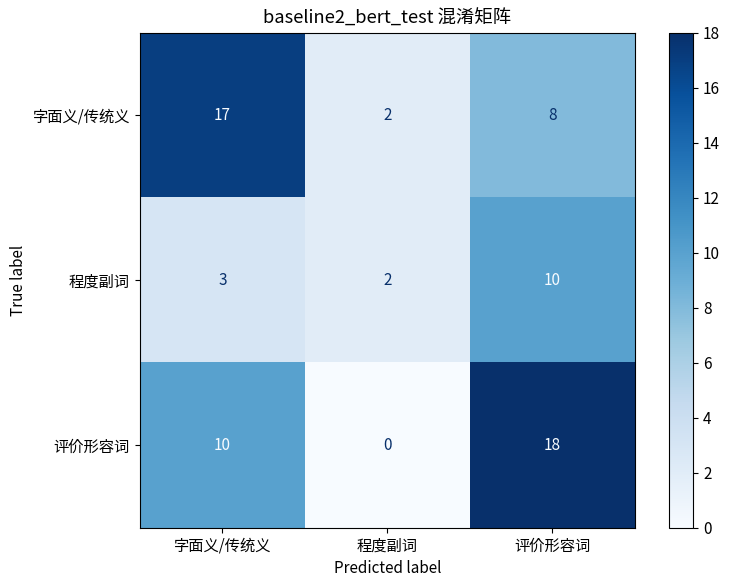

✅ 混淆矩阵图片已保存至：/content/drive/MyDrive/5502/project/result/bert/baseline2_bert_test_confusion_matrix.png
✅ 测试集详细预测已保存至：/content/drive/MyDrive/5502/project/result/bert/baseline2_bert_test_predictions.csv
✅ 结果已缓存至：/content/drive/MyDrive/5502/project/cache/baseline2_bert_cache.pkl

our_bert_mlm


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: /content/drive/MyDrive/5502/project/thunder_mlm_final
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



=== 计算 /content/drive/MyDrive/5502/project/thunder_mlm_final 的MLM困惑度 ===


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

...

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: /content/drive/MyDrive/5502/project/thunder_mlm_final
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,No log,0.914476,0.593750,0.442500
2,0.969528,0.880400,0.656250,0.562963
3,0.496283,0.854779,0.593750,0.513598


Fold 5 准确率: 0.5938, 宏平均F1: 0.5136
已清理临时目录：./temp_fold_4

--- 5折交叉验证汇总结果 ---
准确率: 0.6987 ± 0.0687
宏平均F1: 0.6372 ± 0.0831
验证损失: 0.7307 ± 0.1562
✅ 5折CV分类报告已保存至：/content/drive/MyDrive/5502/project/result/bert_mlm/our_bert_mlm_5fold_cv_report.txt


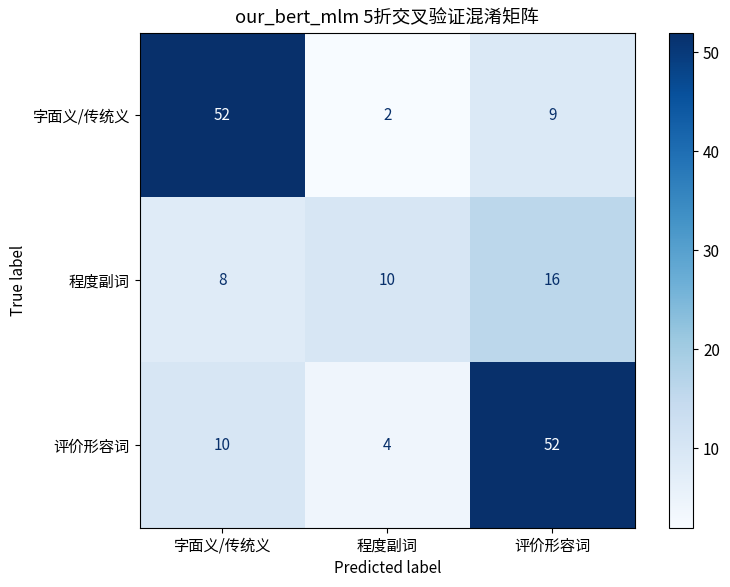

✅ 5折CV混淆矩阵已保存至：/content/drive/MyDrive/5502/project/result/bert_mlm/our_bert_mlm_5fold_cv_confusion_matrix.png

=== 开始完整训练集训练与测试集评估 ===


Map:   0%|          | 0/163 [00:00<?, ? examples/s]

Map:   0%|          | 0/70 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: /content/drive/MyDrive/5502/project/thunder_mlm_final
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
20,1.122135
40,0.815672
60,0.590312


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


--- 最终测试集结果 ---
准确率: 0.7571
宏平均F1: 0.7013
MLM困惑度: 9.0414
✅ 分类报告已保存至：/content/drive/MyDrive/5502/project/result/bert_mlm/our_bert_mlm_test_report.txt


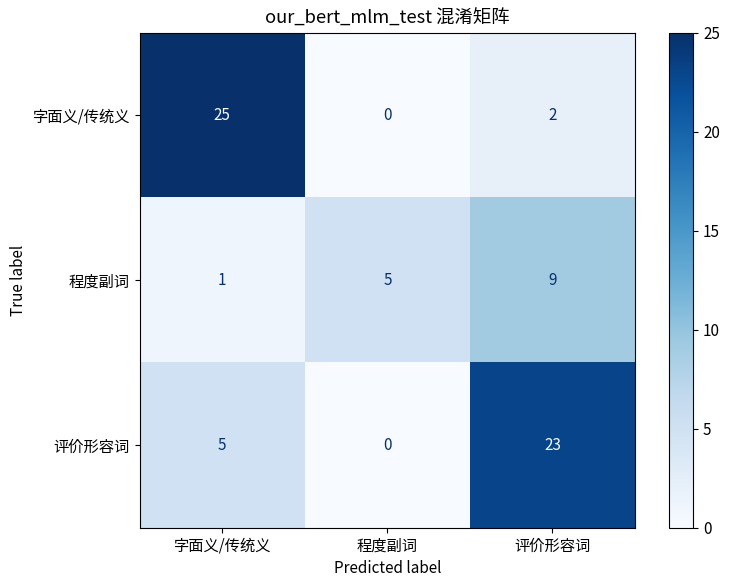

✅ 混淆矩阵图片已保存至：/content/drive/MyDrive/5502/project/result/bert_mlm/our_bert_mlm_test_confusion_matrix.png
✅ 测试集详细预测已保存至：/content/drive/MyDrive/5502/project/result/bert_mlm/our_bert_mlm_test_predictions.csv
✅ 结果已缓存至：/content/drive/MyDrive/5502/project/cache/our_bert_mlm_cache.pkl

🎉 实验流程完成！

📊 困惑度对比：
   原生BERT: 12.2107
   BERT+MLM: 9.0414
   困惑度下降: 3.1694 (25.96%)


In [19]:
# ================== 单元格6：基线2与我们的模型对比（新增困惑度计算） ==================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import shutil
import os
import random
import pickle
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import torch
import torch.nn.functional as F
from transformers import (
    BertTokenizer, BertForSequenceClassification, BertForMaskedLM,
    Trainer, TrainingArguments, DataCollatorWithPadding, DataCollatorForLanguageModeling
)
from datasets import Dataset

# ---------- 全局配置与种子固定 ----------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

# 设备检查
print("GPU可用:", torch.cuda.is_available())
if not torch.cuda.is_available():
    print("⚠️ 警告：未检测到GPU，训练将使用CPU，速度会非常慢！")
else:
    print(f"当前使用GPU: {torch.cuda.get_device_name(0)}")

# 中文字体配置
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'Noto Serif CJK JP', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
print("已设置中文字体：Noto Sans CJK JP")

# ---------- 全局路径配置 ----------
BASE_DIR = "/content/drive/MyDrive/5502/project"
RESULT_DIR = f"{BASE_DIR}/result"
CACHE_DIR = f"{BASE_DIR}/cache"
os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

# ---------- 新增：MLM困惑度计算函数 ----------
def calculate_mlm_perplexity(model_name_or_path, test_df, tokenizer=None, batch_size=16):
    """
    计算预训练模型在测试集上的MLM困惑度
    Args:
        model_name_or_path: 模型路径或名称
        test_df: 测试集DataFrame（包含sentence列）
        tokenizer: 可选，已加载的tokenizer
        batch_size: 批量大小
    Returns:
        平均困惑度
    """
    print(f"\n=== 计算 {model_name_or_path} 的MLM困惑度 ===")

    # 加载模型和tokenizer
    if tokenizer is None:
        if os.path.isdir(model_name_or_path):
            tokenizer = BertTokenizer.from_pretrained(model_name_or_path, local_files_only=True)
        else:
            tokenizer = BertTokenizer.from_pretrained(model_name_or_path)

    if os.path.isdir(model_name_or_path):
        mlm_model = BertForMaskedLM.from_pretrained(model_name_or_path, local_files_only=True)
    else:
        mlm_model = BertForMaskedLM.from_pretrained(model_name_or_path)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    mlm_model.to(device)
    mlm_model.eval()

    # 准备数据
    test_ds = Dataset.from_pandas(test_df[['sentence']])
    def tokenize_function(examples):
        return tokenizer(examples["sentence"], padding="max_length", truncation=True, max_length=64)
    tokenized_test = test_ds.map(tokenize_function, batched=True, remove_columns=["sentence"])
    tokenized_test.set_format("torch", columns=["input_ids", "attention_mask"])

    # 数据整理器（默认15%掩码）
    data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=True, mlm_probability=0.15)

    # 计算困惑度
    total_loss = 0.0
    total_tokens = 0

    with torch.no_grad():
        for i in range(0, len(tokenized_test), batch_size):
            batch = tokenized_test[i:i+batch_size]
            batch = data_collator([{k: v[j] for k, v in batch.items()} for j in range(len(batch['input_ids']))])
            batch = {k: v.to(device) for k, v in batch.items()}

            outputs = mlm_model(**batch)
            loss = outputs.loss
            # 只计算被掩码位置的损失
            mask = batch['labels'] != -100
            total_loss += loss.item() * mask.sum().item()
            total_tokens += mask.sum().item()

    avg_loss = total_loss / total_tokens
    perplexity = torch.exp(torch.tensor(avg_loss)).item()

    print(f"✅ 平均MLM困惑度: {perplexity:.4f}")
    return perplexity

# ---------- 辅助函数 ----------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = (predictions == labels).mean()
    macro_f1 = f1_score(labels, predictions, average='macro')
    return {"accuracy": accuracy, "macro_f1": macro_f1}

def prepare_classification_data(df, tokenizer):
    dataset = Dataset.from_pandas(df[['sentence', 'label']])
    def tokenize(examples):
        return tokenizer(examples["sentence"], truncation=True, max_length=64)
    tokenized = dataset.map(tokenize, batched=True, remove_columns=["sentence"])
    tokenized = tokenized.rename_column("label", "labels")
    tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
    return tokenized

def save_results(y_true, y_pred, target_names, output_dir, model_desc, train_size=None, test_size=None):
    os.makedirs(output_dir, exist_ok=True)
    report = classification_report(y_true, y_pred, target_names=target_names, digits=4)
    report_path = os.path.join(output_dir, f"{model_desc}_report.txt")
    with open(report_path, "w", encoding="utf-8") as f:
        f.write(f"=== {model_desc} 分类报告 ===\n")
        if train_size: f.write(f"训练集大小：{train_size} 条\n")
        if test_size: f.write(f"测试集大小：{test_size} 条\n\n")
        f.write(report)
    print(f"✅ 分类报告已保存至：{report_path}")

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, cmap=plt.cm.Blues, values_format='d')
    plt.title(f"{model_desc} 混淆矩阵")
    plt.tight_layout()
    cm_path = os.path.join(output_dir, f"{model_desc}_confusion_matrix.png")
    plt.savefig(cm_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ 混淆矩阵图片已保存至：{cm_path}")
    return report

def load_model_and_tokenizer(model_name_or_path, num_labels=3):
    """智能加载模型和 tokenizer，自动处理本地路径与 Hub 名称"""
    if os.path.isdir(model_name_or_path):
        tokenizer = BertTokenizer.from_pretrained(model_name_or_path, local_files_only=True)
        model = BertForSequenceClassification.from_pretrained(
            model_name_or_path, num_labels=num_labels, local_files_only=True
        )
    else:
        tokenizer = BertTokenizer.from_pretrained(model_name_or_path)
        model = BertForSequenceClassification.from_pretrained(
            model_name_or_path, num_labels=num_labels
        )
    return tokenizer, model

# ---------- 缓存管理函数 ----------
def check_cache_exists(model_desc):
    """检查是否存在有效的缓存结果"""
    cache_file = os.path.join(CACHE_DIR, f"{model_desc}_cache.pkl")
    result_dir = os.path.join(RESULT_DIR, model_desc.split('_')[0])

    if os.path.exists(cache_file) and os.path.exists(result_dir):
        required_files = [
            f"{model_desc}_5fold_cv_report.txt",
            f"{model_desc}_test_report.txt",
            f"{model_desc}_test_predictions.csv"
        ]
        if all(os.path.exists(os.path.join(result_dir, f)) for f in required_files):
            return True, cache_file
    return False, cache_file

def load_cache(cache_file):
    """加载缓存结果"""
    with open(cache_file, 'rb') as f:
        cache_data = pickle.load(f)
    print(f"✅ 已加载缓存结果：{cache_file}")
    return cache_data

def save_cache(cache_data, cache_file):
    """保存结果到缓存"""
    with open(cache_file, 'wb') as f:
        pickle.dump(cache_data, f)
    print(f"✅ 结果已缓存至：{cache_file}")

# ---------- 核心评估函数（集成困惑度计算） ----------
def run_evaluation(model_name_or_path, model_desc, output_subdir, train_df, test_df, force_retrain=False, calculate_perplexity=True):
    """
    运行单个模型的评估
    Args:
        calculate_perplexity: 是否计算MLM困惑度（仅BERT类模型支持）
    """
    print(f"\n{'='*60}\n{model_desc}\n{'='*60}")

    target_names = ["字面义/传统义", "程度副词", "评价形容词"]
    output_dir = os.path.join(RESULT_DIR, output_subdir)
    os.makedirs(output_dir, exist_ok=True)

    # 检查缓存
    cache_exists, cache_file = check_cache_exists(model_desc)
    if cache_exists and not force_retrain:
        print("ℹ️ 发现缓存结果，跳过训练，直接加载...")
        cache_data = load_cache(cache_file)
        save_results(
            cache_data['y_true'], cache_data['y_pred'],
            target_names, output_dir, model_desc + "_test",
            train_size=len(train_df), test_size=len(test_df)
        )
        return cache_data['y_pred'], cache_data.get('perplexity', None)

    # 使用智能加载函数
    tokenizer, _ = load_model_and_tokenizer(model_name_or_path)

    # 计算MLM困惑度（在微调前，使用原始预训练权重）
    perplexity = None
    if calculate_perplexity:
        perplexity = calculate_mlm_perplexity(model_name_or_path, test_df, tokenizer)

    # ---------- 5折交叉验证 ----------
    print("\n=== 开始5折交叉验证 ===")
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    all_val_preds, all_val_labels, fold_metrics = [], [], []

    for fold, (train_idx, val_idx) in enumerate(skf.split(train_df['sentence'], train_df['label'])):
        print(f"\n--- Fold {fold+1}/5 ---")
        fold_train = train_df.iloc[train_idx].reset_index(drop=True)
        fold_val = train_df.iloc[val_idx].reset_index(drop=True)

        train_ds = prepare_classification_data(fold_train, tokenizer)
        val_ds = prepare_classification_data(fold_val, tokenizer)

        _, model = load_model_and_tokenizer(model_name_or_path, num_labels=3)

        temp_dir = f"./temp_fold_{fold}"
        shutil.rmtree(temp_dir, ignore_errors=True)

        training_args = TrainingArguments(
            output_dir=temp_dir,
            num_train_epochs=3,
            per_device_train_batch_size=8,
            per_device_eval_batch_size=8,
            logging_steps=20,
            eval_strategy="epoch",
            save_strategy="no",
            learning_rate=3e-5,
            seed=42,
            report_to="none",
        )

        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=train_ds,
            eval_dataset=val_ds,
            compute_metrics=compute_metrics,
            data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        )

        trainer.train()
        val_results = trainer.evaluate(val_ds)
        val_preds = np.argmax(trainer.predict(val_ds).predictions, axis=-1)

        fold_metrics.append({
            "accuracy": val_results['eval_accuracy'],
            "macro_f1": val_results['eval_macro_f1'],
            "loss": val_results['eval_loss']
        })
        all_val_preds.extend(val_preds)
        all_val_labels.extend(fold_val['label'].values)

        print(f"Fold {fold+1} 准确率: {val_results['eval_accuracy']:.4f}, 宏平均F1: {val_results['eval_macro_f1']:.4f}")
        shutil.rmtree(temp_dir, ignore_errors=True)
        print(f"已清理临时目录：{temp_dir}")

    # 汇总5折CV
    print("\n--- 5折交叉验证汇总结果 ---")
    accuracies = [m['accuracy'] for m in fold_metrics]
    macro_f1s = [m['macro_f1'] for m in fold_metrics]
    losses = [m['loss'] for m in fold_metrics]
    print(f"准确率: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
    print(f"宏平均F1: {np.mean(macro_f1s):.4f} ± {np.std(macro_f1s):.4f}")
    print(f"验证损失: {np.mean(losses):.4f} ± {np.std(losses):.4f}")

    cv_report = classification_report(all_val_labels, all_val_preds, target_names=target_names, digits=4)
    cv_report_path = os.path.join(output_dir, f"{model_desc}_5fold_cv_report.txt")
    with open(cv_report_path, "w", encoding="utf-8") as f:
        f.write(f"=== {model_desc} 5折交叉验证分类报告 ===\n")
        f.write(f"训练集总样本数：{len(train_df)}\n")
        f.write(f"5折CV准确率：{np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}\n")
        f.write(f"5折CV宏平均F1：{np.mean(macro_f1s):.4f} ± {np.std(macro_f1s):.4f}\n")
        if perplexity is not None:
            f.write(f"测试集MLM困惑度：{perplexity:.4f}\n\n")
        f.write(cv_report)
    print(f"✅ 5折CV分类报告已保存至：{cv_report_path}")

    cv_cm_path = os.path.join(output_dir, f"{model_desc}_5fold_cv_confusion_matrix.png")
    cm = confusion_matrix(all_val_labels, all_val_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, cmap=plt.cm.Blues, values_format='d')
    plt.title(f"{model_desc} 5折交叉验证混淆矩阵")
    plt.tight_layout()
    plt.savefig(cv_cm_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ 5折CV混淆矩阵已保存至：{cv_cm_path}")

    # ---------- 完整训练集训练与测试 ----------
    print("\n=== 开始完整训练集训练与测试集评估 ===")
    full_train_ds = prepare_classification_data(train_df, tokenizer)
    test_ds = prepare_classification_data(test_df, tokenizer)

    _, final_model = load_model_and_tokenizer(model_name_or_path, num_labels=3)

    final_dir = "./final_model"
    shutil.rmtree(final_dir, ignore_errors=True)

    final_training_args = TrainingArguments(
        output_dir=final_dir,
        num_train_epochs=3,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        logging_steps=20,
        learning_rate=3e-5,
        seed=42,
        report_to="none",
    )

    final_trainer = Trainer(
        model=final_model,
        args=final_training_args,
        train_dataset=full_train_ds,
        compute_metrics=compute_metrics,
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    )

    final_trainer.train()
    test_results = final_trainer.evaluate(test_ds)
    test_preds = np.argmax(final_trainer.predict(test_ds).predictions, axis=-1)

    print("\n--- 最终测试集结果 ---")
    print(f"准确率: {test_results['eval_accuracy']:.4f}")
    print(f"宏平均F1: {test_results['eval_macro_f1']:.4f}")
    if perplexity is not None:
        print(f"MLM困惑度: {perplexity:.4f}")

    save_results(test_df['label'].values, test_preds, target_names, output_dir,
                 model_desc + "_test", train_size=len(train_df), test_size=len(test_df))

    pred_df = pd.DataFrame({
        'sentence': test_df['sentence'].values,
        'true_label': test_df['label'].values,
        'true_label_name': [target_names[l] for l in test_df['label'].values],
        'pred_label': test_preds,
        'pred_label_name': [target_names[l] for l in test_preds]
    })
    pred_csv_path = os.path.join(output_dir, f"{model_desc}_test_predictions.csv")
    pred_df.to_csv(pred_csv_path, index=False, encoding='utf-8-sig')
    print(f"✅ 测试集详细预测已保存至：{pred_csv_path}")

    shutil.rmtree(final_dir, ignore_errors=True)

    # 保存缓存（包含困惑度）
    cache_data = {
        'y_true': test_df['label'].values,
        'y_pred': test_preds,
        'fold_metrics': fold_metrics,
        'perplexity': perplexity
    }
    save_cache(cache_data, cache_file)

    return test_preds, perplexity

# ---------- 主执行流程 ----------
if __name__ == "__main__":
    print("\n" + "="*60)
    print("开始实验：基线2（原生BERT） vs 我们的模型（BERT+MLM）")
    print("="*60)

    # 读取数据
    train_df = pd.read_csv(f"{BASE_DIR}/train_set.csv")
    test_df = pd.read_csv(f"{BASE_DIR}/test_set.csv")

    print(f"训练集大小：{len(train_df)}，测试集大小：{len(test_df)}")
    print("训练集类别分布：")
    print(train_df['label'].value_counts().sort_index())
    print("测试集类别分布：")
    print(test_df['label'].value_counts().sort_index())

    # ========== 配置区域 ==========
    RUN_BASELINE2 = True
    FORCE_RETRAIN_BASELINE = True  # 设为True强制重训，计算困惑度
    RUN_OUR_MODEL = True
    FORCE_RETRAIN_OUR_MODEL = True  # 设为True强制重训，计算困惑度
    # ===============================================

    # 基线2：原生BERT
    baseline2_perplexity = None
    if RUN_BASELINE2:
        baseline2_preds, baseline2_perplexity = run_evaluation(
            "bert-base-chinese",
            "baseline2_bert",
            "bert",
            train_df,
            test_df,
            force_retrain=FORCE_RETRAIN_BASELINE,
            calculate_perplexity=True
        )

    # 我们的模型：BERT + MLM继续预训练
    our_perplexity = None
    if RUN_OUR_MODEL:
        our_model_path = f"{BASE_DIR}/thunder_mlm_final"
        if not os.path.isdir(our_model_path):
            print(f"\n❌ 错误：未找到MLM模型目录 {our_model_path}")
            print("💡 提示：请先运行【单元格5】完成MLM继续预训练！")
        else:
            our_preds, our_perplexity = run_evaluation(
                our_model_path,
                "our_bert_mlm",
                "bert_mlm",
                train_df,
                test_df,
                force_retrain=FORCE_RETRAIN_OUR_MODEL,
                calculate_perplexity=True
            )

    print("\n" + "="*60)
    print("🎉 实验流程完成！")
    if baseline2_perplexity and our_perplexity:
        print(f"\n📊 困惑度对比：")
        print(f"   原生BERT: {baseline2_perplexity:.4f}")
        print(f"   BERT+MLM: {our_perplexity:.4f}")
        print(f"   困惑度下降: {(baseline2_perplexity - our_perplexity):.4f} ({(1 - our_perplexity/baseline2_perplexity)*100:.2f}%)")
    print("="*60)


开始读取实验结果...
⚠️  未找到：TF-IDF+SVM 的结果文件，跳过
✅ 已加载：原生BERT
   测试集准确率: 0.5286, 宏F1: 0.4565
   MLM困惑度: 12.2107
✅ 已加载：BERT+MLM(我们的)
   测试集准确率: 0.7571, 宏F1: 0.7013
   MLM困惑度: 9.0414

开始生成对比图...


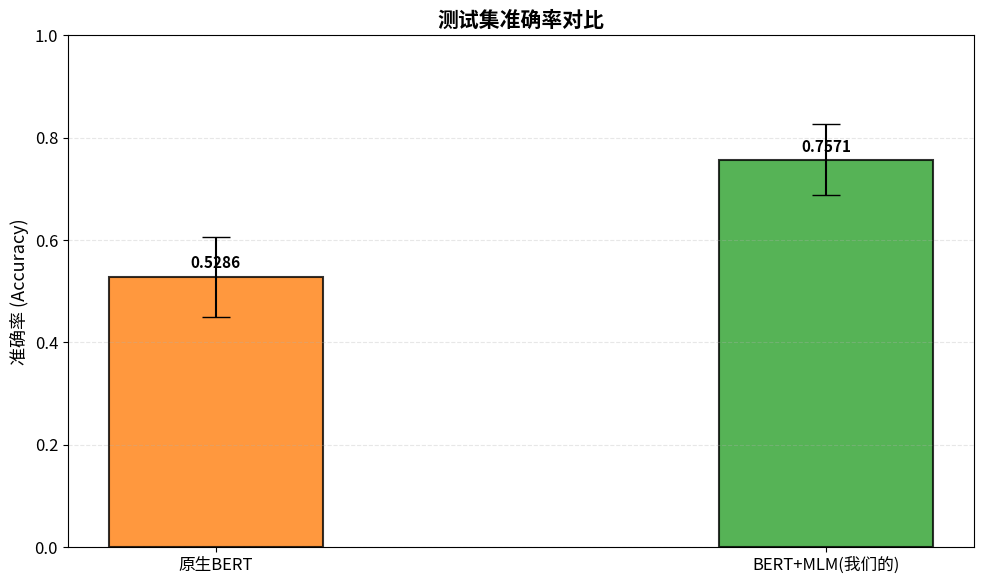

✅ 准确率对比图已保存


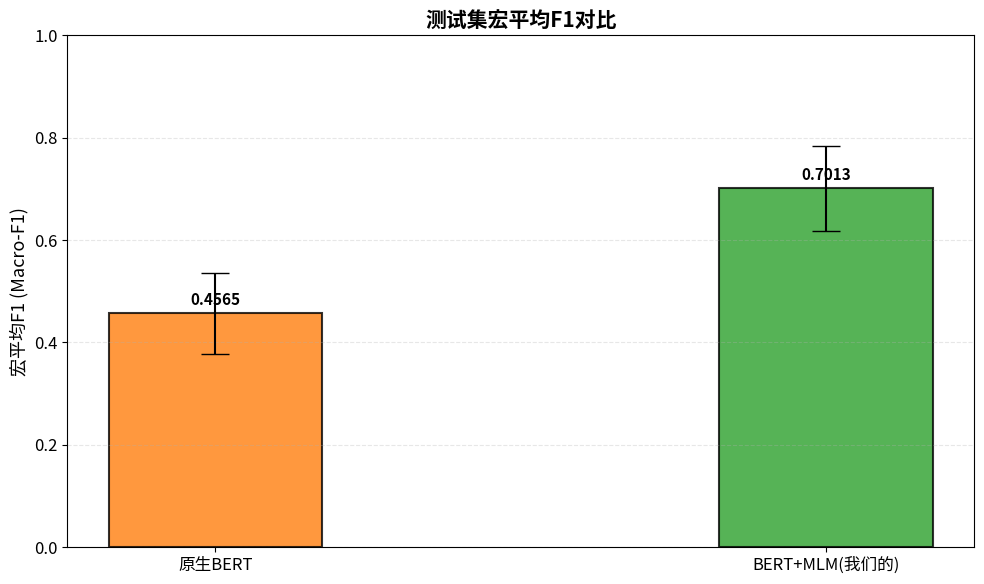

✅ 宏F1对比图已保存


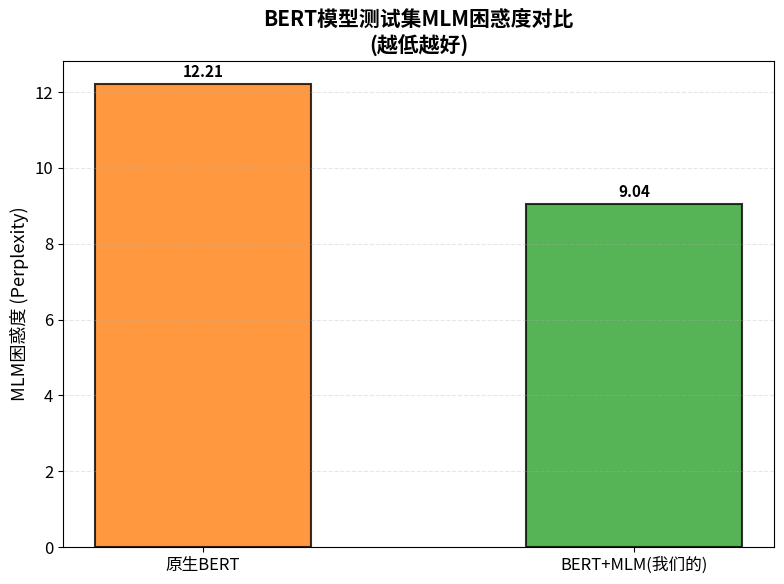

✅ 困惑度对比图已保存


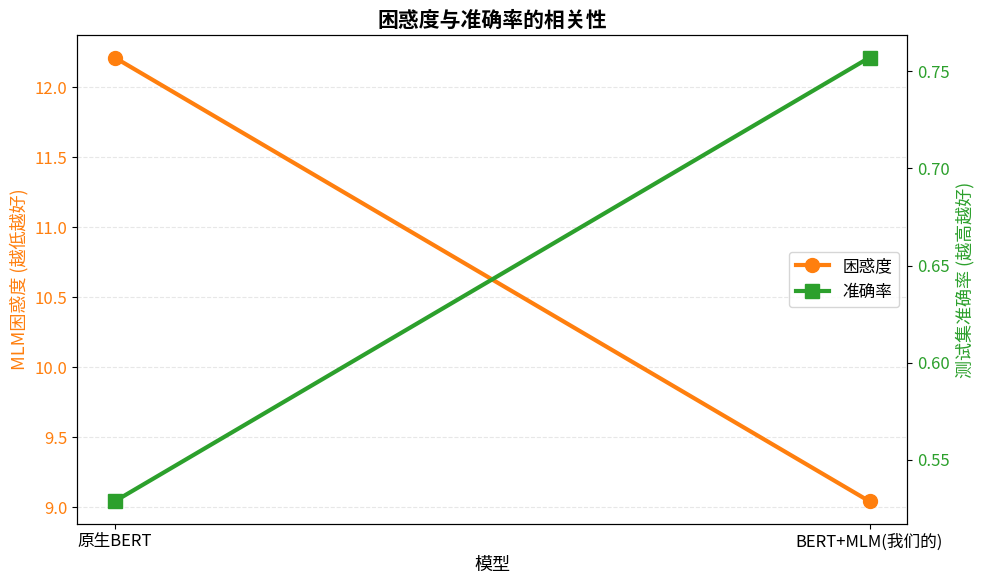

✅ 困惑度-准确率相关性图已保存

📊 实验结果汇总表
           模型 测试集准确率 测试集宏F1 测试集MLM困惑度 5折CV准确率(均值±标准差) 5折CV宏F1(均值±标准差)
       原生BERT 0.5286 0.4565   12.2107   0.5576±0.0781   0.4333±0.0800
BERT+MLM(我们的) 0.7571 0.7013    9.0414   0.6987±0.0687   0.6372±0.0831

✅ 结果汇总表已保存至：/content/drive/MyDrive/5502/project/result/comparison/result_summary_with_perplexity.csv

🎉 所有可视化完成！
📁 结果目录：/content/drive/MyDrive/5502/project/result/comparison


In [20]:
# ================== 单元格7：实验结果综合可视化对比（新增困惑度） ==================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import os
import pickle
from sklearn.metrics import accuracy_score, f1_score

# ---------- 全局配置 ----------
BASE_DIR = "/content/drive/MyDrive/5502/project"
RESULT_DIR = f"{BASE_DIR}/result"
COMPARISON_DIR = f"{RESULT_DIR}/comparison"
CACHE_DIR = f"{BASE_DIR}/cache"
os.makedirs(COMPARISON_DIR, exist_ok=True)

# 中文字体配置
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'Noto Serif CJK JP', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['font.size'] = 12

# ---------- 辅助函数 ----------
def load_classification_results(pred_csv_path):
    df = pd.read_csv(pred_csv_path)
    y_true = df['true_label'].values
    y_pred = df['pred_label'].values
    return y_true, y_pred

def load_cv_metrics_and_perplexity(cache_path):
    if os.path.exists(cache_path):
        with open(cache_path, 'rb') as f:
            cache_data = pickle.load(f)
        fold_metrics = cache_data['fold_metrics']
        acc_mean = np.mean([m['accuracy'] for m in fold_metrics])
        acc_std = np.std([m['accuracy'] for m in fold_metrics])
        f1_mean = np.mean([m['macro_f1'] for m in fold_metrics])
        f1_std = np.std([m['macro_f1'] for m in fold_metrics])
        perplexity = cache_data.get('perplexity', None)
        return acc_mean, acc_std, f1_mean, f1_std, perplexity
    else:
        return None, None, None, None, None

# ---------- 读取所有结果 ----------
print("\n" + "="*60)
print("开始读取实验结果...")
print("="*60)

model_info = {
    "TF-IDF+SVM": {
        "pred_csv": f"{RESULT_DIR}/svm/baseline1_svm_test_predictions.csv",
        "cache": None,
        "color": "#1f77b4"
    },
    "原生BERT": {
        "pred_csv": f"{RESULT_DIR}/bert/baseline2_bert_test_predictions.csv",
        "cache": f"{CACHE_DIR}/baseline2_bert_cache.pkl",
        "color": "#ff7f0e"
    },
    "BERT+MLM(我们的)": {
        "pred_csv": f"{RESULT_DIR}/bert_mlm/our_bert_mlm_test_predictions.csv",
        "cache": f"{CACHE_DIR}/our_bert_mlm_cache.pkl",
        "color": "#2ca02c"
    }
}

results = {}
for model_name, paths in model_info.items():
    if os.path.exists(paths['pred_csv']):
        y_true, y_pred = load_classification_results(paths['pred_csv'])
        test_acc = accuracy_score(y_true, y_pred)
        test_f1 = f1_score(y_true, y_pred, average='macro')

        cv_acc_mean, cv_acc_std, cv_f1_mean, cv_f1_std, perplexity = load_cv_metrics_and_perplexity(paths['cache'])

        results[model_name] = {
            "test_acc": test_acc,
            "test_f1": test_f1,
            "cv_acc_mean": cv_acc_mean,
            "cv_acc_std": cv_acc_std,
            "cv_f1_mean": cv_f1_mean,
            "cv_f1_std": cv_f1_std,
            "perplexity": perplexity,
            "color": paths['color']
        }
        print(f"✅ 已加载：{model_name}")
        print(f"   测试集准确率: {test_acc:.4f}, 宏F1: {test_f1:.4f}")
        if perplexity is not None:
            print(f"   MLM困惑度: {perplexity:.4f}")
    else:
        print(f"⚠️  未找到：{model_name} 的结果文件，跳过")

if len(results) < 2:
    print("\n❌ 错误：结果文件不足，无法生成对比图！")
    exit()

# ---------- 生成对比图 ----------
print("\n" + "="*60)
print("开始生成对比图...")
print("="*60)

# --- 图1：测试集准确率对比 ---
model_names = list(results.keys())
colors = [results[m]['color'] for m in model_names]
x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
test_accs = [results[m]['test_acc'] for m in model_names]
error_bars = [results[m]['cv_acc_std'] if results[m]['cv_acc_std'] is not None else 0 for m in model_names]

bars = ax.bar(x, test_accs, width, yerr=error_bars, capsize=10, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylabel('准确率 (Accuracy)', fontsize=13)
ax.set_title('测试集准确率对比', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=12)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(f"{COMPARISON_DIR}/comparison_accuracy.png", dpi=200, bbox_inches='tight')
plt.show()
print("✅ 准确率对比图已保存")

# --- 图2：测试集宏F1对比 ---
fig, ax = plt.subplots(figsize=(10, 6))
test_f1s = [results[m]['test_f1'] for m in model_names]
error_bars_f1 = [results[m]['cv_f1_std'] if results[m]['cv_f1_std'] is not None else 0 for m in model_names]

bars = ax.bar(x, test_f1s, width, yerr=error_bars_f1, capsize=10, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylabel('宏平均F1 (Macro-F1)', fontsize=13)
ax.set_title('测试集宏平均F1对比', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=12)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(f"{COMPARISON_DIR}/comparison_macro_f1.png", dpi=200, bbox_inches='tight')
plt.show()
print("✅ 宏F1对比图已保存")

# --- 图3：BERT模型困惑度对比（仅展示有困惑度的模型） ---
bert_models = [m for m in model_names if results[m]['perplexity'] is not None]
if len(bert_models) >= 2:
    fig, ax = plt.subplots(figsize=(8, 6))
    perplexities = [results[m]['perplexity'] for m in bert_models]
    bert_colors = [results[m]['color'] for m in bert_models]
    x_bert = np.arange(len(bert_models))

    bars = ax.bar(x_bert, perplexities, width=0.5, color=bert_colors, alpha=0.8, edgecolor='black', linewidth=1.5)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{height:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

    ax.set_ylabel('MLM困惑度 (Perplexity)', fontsize=13)
    ax.set_title('BERT模型测试集MLM困惑度对比\n(越低越好)', fontsize=15, fontweight='bold')
    ax.set_xticks(x_bert)
    ax.set_xticklabels(bert_models, fontsize=12)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.savefig(f"{COMPARISON_DIR}/comparison_perplexity.png", dpi=200, bbox_inches='tight')
    plt.show()
    print("✅ 困惑度对比图已保存")

# --- 图4：困惑度-准确率相关性图 ---
if len(bert_models) >= 2:
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # 左Y轴：困惑度
    ax1.set_xlabel('模型', fontsize=13)
    ax1.set_ylabel('MLM困惑度 (越低越好)', color='#ff7f0e', fontsize=13)
    line1 = ax1.plot(x_bert, perplexities, color='#ff7f0e', marker='o', linewidth=3, markersize=10, label='困惑度')
    ax1.tick_params(axis='y', labelcolor='#ff7f0e')
    ax1.grid(axis='y', alpha=0.3, linestyle='--')

    # 右Y轴：准确率
    ax2 = ax1.twinx()
    accs_bert = [results[m]['test_acc'] for m in bert_models]
    line2 = ax2.plot(x_bert, accs_bert, color='#2ca02c', marker='s', linewidth=3, markersize=10, label='准确率')
    ax2.set_ylabel('测试集准确率 (越高越好)', color='#2ca02c', fontsize=13)
    ax2.tick_params(axis='y', labelcolor='#2ca02c')

    # 添加图例
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='center right', fontsize=12)

    ax1.set_xticks(x_bert)
    ax1.set_xticklabels(bert_models, fontsize=12)
    ax1.set_title('困惑度与准确率的相关性', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{COMPARISON_DIR}/perplexity_accuracy_correlation.png", dpi=200, bbox_inches='tight')
    plt.show()
    print("✅ 困惑度-准确率相关性图已保存")

# ---------- 生成结果汇总表 ----------
print("\n" + "="*60)
print("📊 实验结果汇总表")
print("="*60)
summary_df = pd.DataFrame({
    "模型": model_names,
    "测试集准确率": [f"{results[m]['test_acc']:.4f}" for m in model_names],
    "测试集宏F1": [f"{results[m]['test_f1']:.4f}" for m in model_names],
    "测试集MLM困惑度": [f"{results[m]['perplexity']:.4f}" if results[m]['perplexity'] is not None else "-" for m in model_names],
    "5折CV准确率(均值±标准差)": [
        f"{results[m]['cv_acc_mean']:.4f}±{results[m]['cv_acc_std']:.4f}" if results[m]['cv_acc_mean'] is not None else "-"
        for m in model_names
    ],
    "5折CV宏F1(均值±标准差)": [
        f"{results[m]['cv_f1_mean']:.4f}±{results[m]['cv_f1_std']:.4f}" if results[m]['cv_f1_mean'] is not None else "-"
        for m in model_names
    ]
})
print(summary_df.to_string(index=False))

summary_path = f"{COMPARISON_DIR}/result_summary_with_perplexity.csv"
summary_df.to_csv(summary_path, index=False, encoding='utf-8-sig')
print(f"\n✅ 结果汇总表已保存至：{summary_path}")

print("\n" + "="*60)
print("🎉 所有可视化完成！")
print(f"📁 结果目录：{COMPARISON_DIR}")
print("="*60)